# <center><font color='green'>Desafío - Introducción al Machine Learning</font></center>

1. Leer el archivo Retail_Invoices.xlsx y realizar un análisis de calidad de datos, para
definir la calidad de la data entregada considerando valores anómalos, valores
faltantes, etc. Limpia lo que sea necesario y realiza un análisis exploratorio de los
datos considerando gráficos de distribuciones y correlaciones entre estos.

In [1]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos el dataframe usando 'pd.read_csv()'.
df= pd.read_excel('Retail_Invoices.xlsx')

# Mostramos el dataframe creado.
df

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
0,536365,2010-12-01,17850,40,139.12,7
1,536366,2010-12-01,17850,12,22.20,2
2,536367,2010-12-01,13047,83,278.73,12
3,536368,2010-12-01,13047,15,70.05,4
4,536369,2010-12-01,13047,3,17.85,1
...,...,...,...,...,...,...
22185,C581484,2011-12-09,16446,-80995,-168469.60,1
22186,C581490,2011-12-09,14397,-23,-32.53,2
22187,C581499,2011-12-09,15498,-1,-224.69,1
22188,C581568,2011-12-09,15311,-5,-54.75,1


In [2]:
# Mostramos un resumen.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22190 entries, 0 to 22189
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    22190 non-null  object        
 1   InvoiceDate  22190 non-null  datetime64[ns]
 2   CustomerID   22190 non-null  int64         
 3   Quantity     22190 non-null  int64         
 4   price_total  22190 non-null  float64       
 5   StockCode    22190 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 1.0+ MB


In [3]:
# Definimos la función informe de calidad del dataframe.
def diagnostico_calidad(df):
    print("=== DIAGNÓSTICO DE CALIDAD DE DATOS ===\n")
    
    # 1. Valores Faltantes.
    print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")
    
    # 2. Duplicados.
    print(f"Filas duplicadas: {df.duplicated().sum()}")
    
    # 3. Análisis de valores anómalos (negativos o cero).
    print("\nValores inconsistentes (Cero o Negativos):")
    anomalos_qty = df[df['Quantity'] <= 0].shape[0]
    anomalos_price = df[df['price_total'] <= 0].shape[0]
    print(f"- Boletas con Quantity <= 0: {anomalos_qty}")
    print(f"- Boletas con price_total <= 0: {anomalos_price}")
    
    # 4. Estadísticos principales
    print("\nResumen Estadístico:")
    display(df.describe())

In [3]:
# Ejecutamos la función definida anteriormente para mostrar el informe.
diagnostico_calidad(df)

=== DIAGNÓSTICO DE CALIDAD DE DATOS ===

Valores nulos por columna:
InvoiceNo      0
InvoiceDate    0
CustomerID     0
Quantity       0
price_total    0
StockCode      0
dtype: int64

Filas duplicadas: 0

Valores inconsistentes (Cero o Negativos):
- Boletas con Quantity <= 0: 3654
- Boletas con price_total <= 0: 3658

Resumen Estadístico:


,InvoiceDate,CustomerID,Quantity,price_total,StockCode
count,22190,22190.000000,22190.000000,22190.000000,22190.000000
mean,2011-06-29 05:59:15.223073536,15238.498738,221.130599,374.045327,18.333889
min,2010-12-01 00:00:00,12346.000000,-80995.000000,-168469.600000,1.000000
25%,2011-03-29 00:00:00,13755.000000,30.000000,87.962500,3.000000
50%,2011-07-08 00:00:00,15136.000000,120.000000,241.505000,12.000000
75%,2011-10-10 00:00:00,16746.000000,254.000000,418.022500,24.000000
max,2011-12-09 00:00:00,18287.000000,80995.000000,168469.600000,542.000000
std,NaN,1733.149624,1170.215301,2018.482869,23.892111


In [4]:
# Ahora vamos a limpiar los datos. 
# Los valores negativos suelen representar devoluciones, 
# para una segmentación de comportamiento de compra vamos a eliminarlos.

# Eliminamos registros con cantidades o precios no positivos.
df_limpio= df[(df['Quantity'] > 0) & (df['price_total'] > 0)]

print(f"Registros después de la limpieza: {df_limpio.shape[0]}")

Registros después de la limpieza: 18532


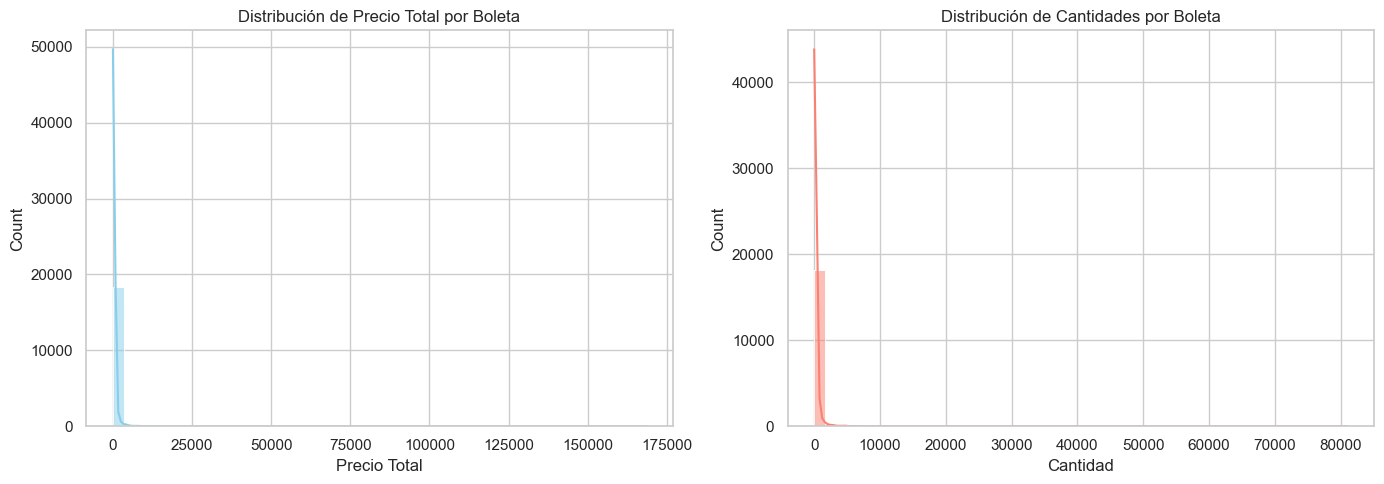

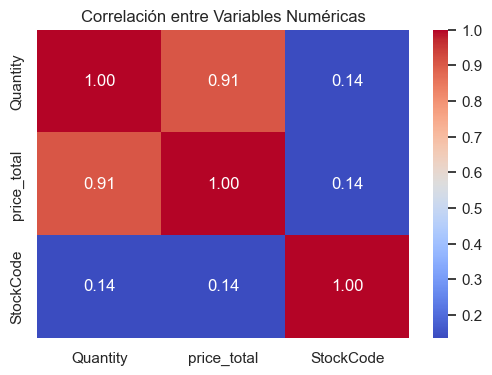

In [5]:
# Ahora visualizamos cómo se distribuyen las compras en FreshMart.
# Configuración de estilo.
sns.set_theme(style="whitegrid")

# A. Distribución de Cantidades y Precios Totales.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_limpio['price_total'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de Precio Total por Boleta')
plt.xlabel('Precio Total')

plt.subplot(1, 2, 2)
sns.histplot(df_limpio['Quantity'], bins=50, kde=True, color='salmon')
plt.title('Distribución de Cantidades por Boleta')
plt.xlabel('Cantidad')

plt.tight_layout()
plt.show()

# B. Análisis de Correlación.
plt.figure(figsize=(6, 4))
# Solo columnas numéricas para la correlación.
numeric_cols = df_limpio[['Quantity', 'price_total', 'StockCode']]
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas')
plt.show()

#### Diagnóstico de Calidad:
- Estado Inicial: 22,190 registros sin valores nulos ni duplicados.
- Hallazgo: Se detectaron 3,658 boletas con valores negativos (posibles devoluciones o errores de sistema).
- Limpieza: Se eliminaron estos registros para no afectar el modelo de segmentación, quedando un dataset final de 18,532 filas.
#### Análisis Exploratorio: 
- Distribuciones:La mayoría hace compras pequeñas, pero existen "outliers" que representan clientes de alto valor o mayoristas.
- Correlaciones: Existe una relación entre el volumen de productos y el monto total de la boleta.
- Conclusión: Los datos están limpios y muestran una dispersión clara.

2. Generar variables para la segmentación. Notar que la granularidad de la data es por
boleta y se necesita segmentar clientes, por lo que es necesario generar variables a
nivel de clientes. Se propone generar al menos RFM (Recencia, frecuencia y monto).

In [6]:
# Definimos la fecha de referencia (un día después de la última factura).
fecha_referencia = df_limpio['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agrupamos por CustomerID y calculamos las métricas.
rfm = df_limpio.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (fecha_referencia - x.max()).days, # Recencia
    'InvoiceNo': 'count',                                     # Frecuencia
    'price_total': 'sum'                                      # Monto (Monetary)
})

# Renombramos las columnas.
rfm.rename(columns={
    'InvoiceDate': 'Recencia',
    'InvoiceNo': 'Frecuencia',
    'price_total': 'Monto'
}, inplace=True)

# Agregamos una variable de "Variedad" (promedio de StockCodes comprados).
variedad = df_limpio.groupby('CustomerID')['StockCode'].mean()
rfm['Variedad'] = variedad

print("Tabla RFM generada:")
display(rfm.head())

Tabla RFM generada:


,Recencia,Frecuencia,Monto,Variedad
CustomerID,,,,
12346,326,1,77183.60,1.00
12347,3,7,4310.00,26.00
12348,76,4,1797.24,7.75
12349,19,1,1757.55,73.00
12350,311,1,334.40,17.00


3. Realizar un análisis exploratorio y las transformaciones necesarias a las nuevas
variables.

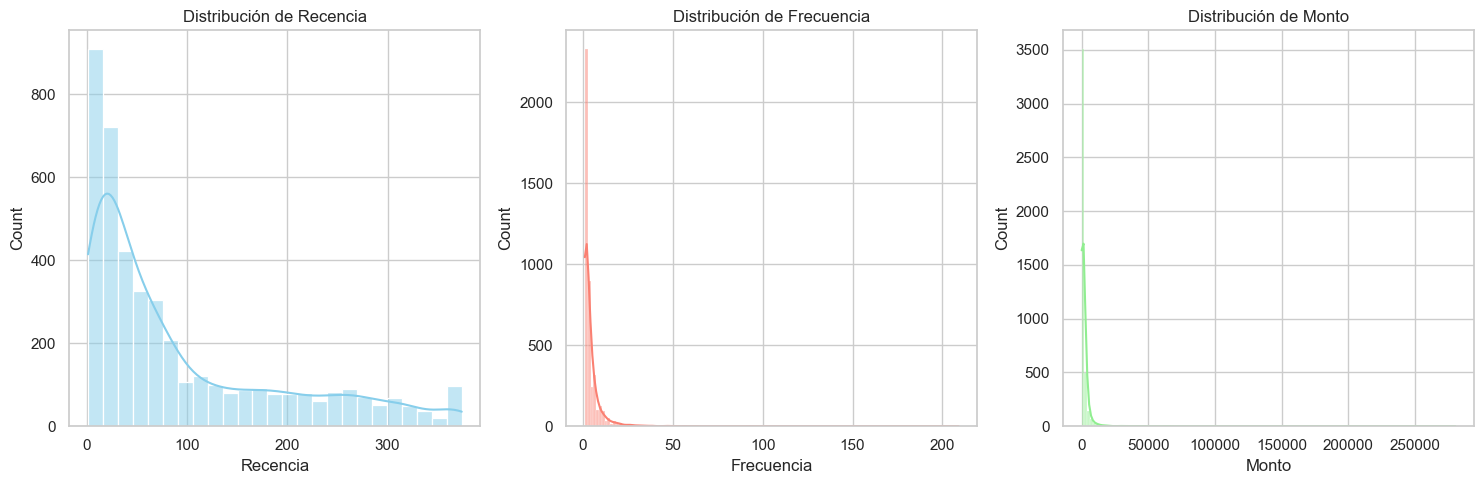

In [8]:
# Realizamos un análisis exploratorio de las Variables RFM.
# Para poder entender cómo se distribuyen estas nuevas métricas.

# Visualización de distribuciones.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recencia'], kde=True, color="skyblue")
plt.title('Distribución de Recencia')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frecuencia'], kde=True, color="salmon")
plt.title('Distribución de Frecuencia')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monto'], kde=True, color="lightgreen")
plt.title('Distribución de Monto')

plt.tight_layout()
plt.show()

##### Podemos obvesrvar que en las variables 'Frecuencia' y 'Monto' existe un sesgo muy fuerte a la derecha, una distribución asimétrica.

#### Transformaciones. 
##### Para que el modelo de Clustering (como K-Means) funcione bien vamos a:

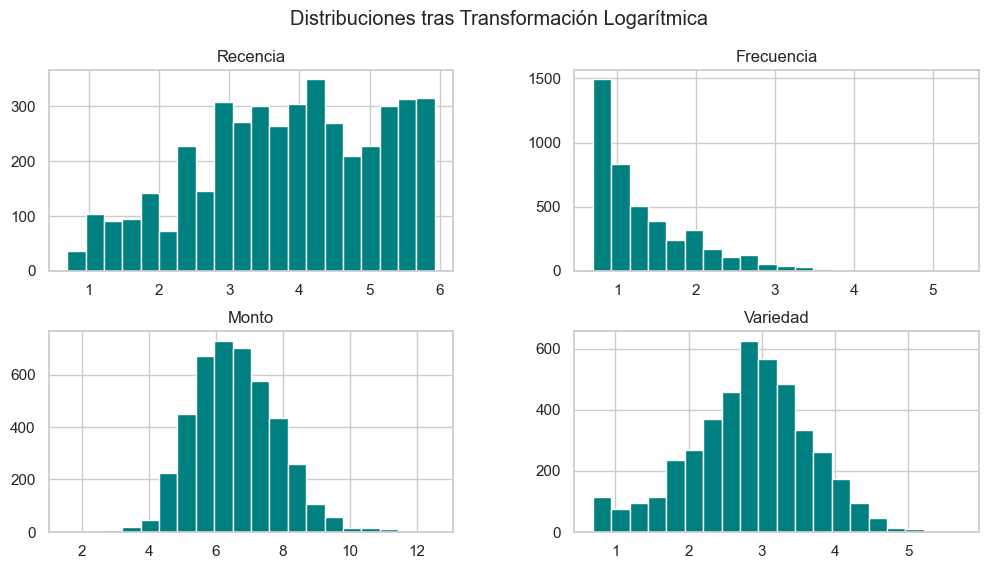

In [9]:
# 1. Realizar una transformación logarítmica. 
# Aplicamos el logaritmo para "comprimir" los valores extremos y que la distribución se parezca más a una campana normal.
# Aplicamos logaritmo (sumamos 1 para evitar problemas con valores de 0).
rfm_log = np.log(rfm + 1)

# Verificamos cómo quedaron las distribuciones ahora.
rfm_log.hist(figsize=(12, 6), bins=20, color='teal')
plt.suptitle("Distribuciones tras Transformación Logarítmica")
plt.show()

In [10]:
# 2. Realizamos una estandarización.
# Para que el algoritmo no le dé más importancia a una variable sobre otra.

# Primero traemos la herramienta de la biblioteca.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convertimos de nuevo a DataFrame para que sea fácil de leer.
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("Datos listos para Clustering:")
display(rfm_scaled_df.head())

Datos listos para Clustering:


,Recencia,Frecuencia,Monto,Variedad
CustomerID,,,,
12346,1.478884,-0.955214,3.706225,-2.600248
12347,-1.890642,1.074425,1.411843,0.565842
12348,0.372339,0.386304,0.716489,-0.804854
12349,-0.659158,-0.955214,0.698739,1.792320
12350,1.442954,-0.955214,-0.618962,0.072606


4. Aplicar al menos 2 algoritmos de clustering. Buscar el número indicado de clusters
que pueden tener y visualizar los cluster resultantes de los algoritmos.

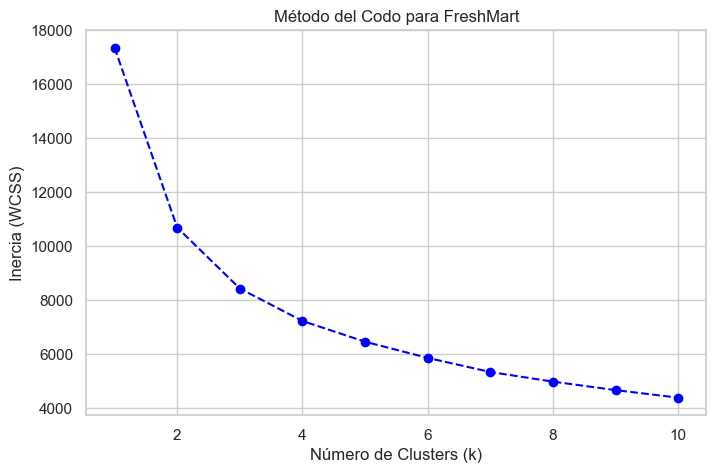

In [19]:
# Importamos las herramientas necesarias.
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering

# Algoritmo 1: K-Means y el Método del Codo.
# Calculamos la inercia para diferentes cantidades de clusters.
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled_df)
    inercia.append(model.inertia_)

# Graficamos el Método del Codo.
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='blue')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para FreshMart')
plt.grid(True)
plt.show()

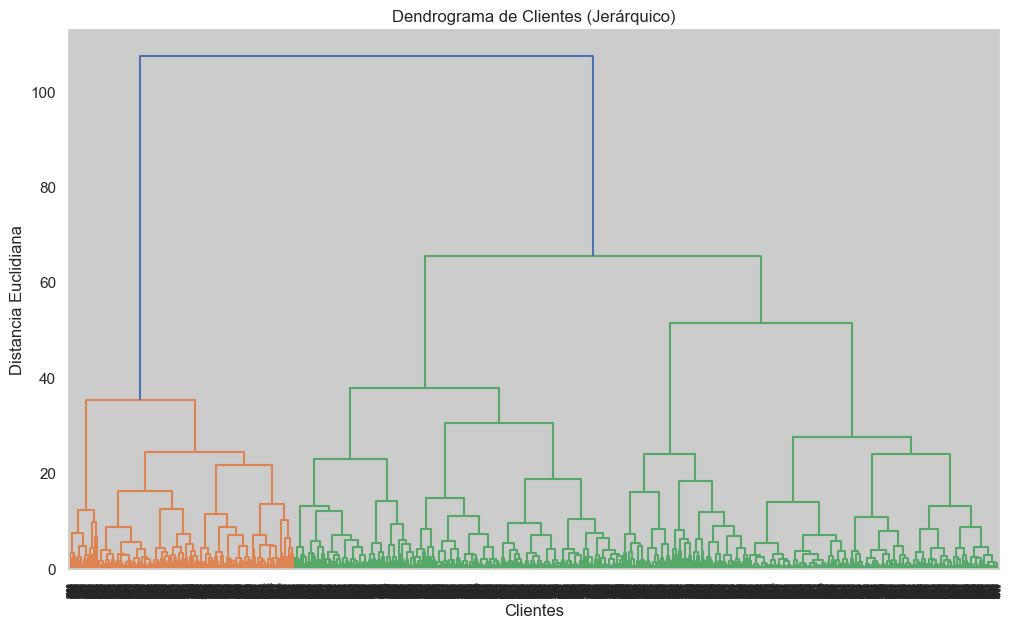

In [15]:
# Algoritmo 2: Clustering Jerárquico.
plt.figure(figsize=(12, 7))
plt.title('Dendrograma de Clientes (Jerárquico)')

# Usamos el método 'ward' que minimiza la varianza dentro de los grupos.
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled_df, method='ward'))
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.show()

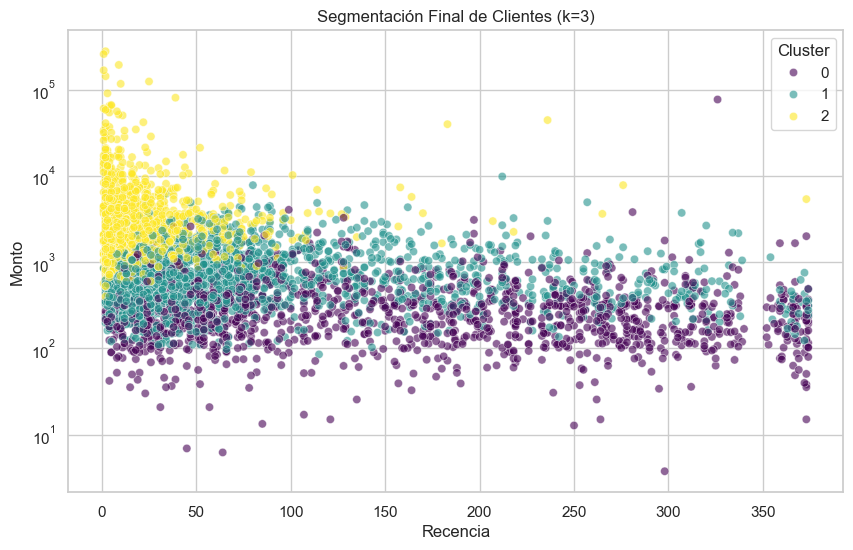

In [16]:
# Aplicamos y visualizamos los resultados.

# Aplicamos K-Means con el k elegido (3)
k_ideal = 3
kmeans_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled_df)

# Visualización: Recencia vs Monto.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recencia', y='Monto', hue='Cluster', palette='viridis', alpha=0.6)
plt.yscale('log') # Usamos escala logarítmica para ver mejor la dispersión del dinero
plt.title(f'Segmentación Final de Clientes (k={k_ideal})')
plt.show()

#### Conclusión: 
- Se aplicaron dos algoritmos de clustering: K-Means y clustering jerárquico, con el objetivo de segmentar a los clientes según sus características RFM.
- A partir del método del codo, se observa que la inercia disminuye de forma pronunciada hasta k = 3, a partir del cual la mejora se vuelve más gradual. Esto indica que 3 clusters es una cantidad adecuada.
- El dendrograma del clustering jerárquico refuerza esta decisión, mostrando una separación natural en aproximadamente tres grandes grupos antes de que las distancias de fusión aumenten significativamente.
- Finalmente, al visualizar los clusters en el gráfico de Recencia vs Monto, se identifican tres segmentos bien diferenciados:
1.  Un grupo de clientes con bajo gasto (Monto bajo) y variada recencia.
2. Un grupo intermedio con gasto moderado.
3. Un grupo de clientes con alto gasto, principalmente con baja recencia (más recientes), lo que sugiere clientes valiosos y activos.
- En conclusión, ambos métodos coinciden en la existencia de tres segmentos principales de clientes, lo que permite identificar perfiles diferenciados y potencialmente diseñar estrategias específicas para cada grupo.

5. Evaluar la calidad de los clustering de forma numérica y realizar una explicación de
cada segmento asignándoles un nombre descriptivo.

In [18]:
# Evaluación de K-Means:

# Variables.
X = rfm_scaled_df
labels = rfm['Cluster']

# 1. Silhouette Score.
silhouette = silhouette_score(X, labels)

# 2. Davies-Bouldin Index.
davies_bouldin = davies_bouldin_score(X, labels)

# 3. SSE (Inercia de K-Means).
sse = kmeans_final.inertia_

# Mostramos resultados.
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", davies_bouldin)
print("SSE (Inercia):", sse)

Silhouette Score: 0.26488654200774614
Davies-Bouldin Index: 1.248123149349432
SSE (Inercia): 8426.086821655505


In [20]:
# Evaluación del clustering jerárquico:

# Aplicar clustering jerárquico con 3 clusters.
jerarquico = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_jer = jerarquico.fit_predict(rfm_scaled_df)

# Métricas.
sil_jer = silhouette_score(rfm_scaled_df, labels_jer)
db_jer = davies_bouldin_score(rfm_scaled_df, labels_jer)

print("Silhouette Jerárquico:", sil_jer)
print("Davies-Bouldin Jerárquico:", db_jer)

Silhouette Jerárquico: 0.19621480400025562
Davies-Bouldin Jerárquico: 1.537323055476686


#### Conclusiones: 
1. **Comparativa de los algoritmos:**
- Se aplicaron los algoritmos de K-Means y clustering jerárquico para segmentar a los clientes en tres grupos. En el caso de K-Means, se obtuvo un coeficiente de Silhouette de 0.26 y un índice de Davies-Bouldin de 1.25, lo que indica una separación moderada y una diferenciación aceptable entre los clusters.
Por otro lado, el clustering jerárquico presentó un Silhouette de 0.19 y un índice de Davies-Bouldin de 1.53, evidenciando una menor calidad en la separación y mayor similitud entre los grupos en comparación con K-Means.
En base a estas métricas, K-Means ofrece un mejor desempeño, logrando clusters más compactos y mejor definidos. El método jerárquico, si bien resulta útil para explorar la estructura de los datos mediante el dendrograma, no alcanza el mismo nivel de precisión en la segmentación. Por lo tanto, se selecciona K-Means como el modelo más adecuado para la segmentación final.
2. **Explicación de los segmentos:**
   - Cluster 0 → “Clientes ocasionales” Bajo nivel de gasto. Compras poco frecuentes o antiguas. Son clientes con baja vinculación. Podemos decir que: Generan poco valor y hay riesgo de abandono alto.
   - Cluster 1 → “Clientes regulares” Gasto medio. Frecuencia moderada. Mantienen cierta estabilidad en compras. Podemos decir que: Son clientes recuperables y fidelizables y tiene potencial de crecimiento.
   - Cluster 2 → “Clientes premium” Alto nivel de gasto. Compras recientes (baja recencia). Son los clientes más valiosos. Podemos decir que: tiene alta rentabilidad y alta fidelidad. 